# 1주차 실습 — Upworthy 헤드라인 A/B 실험

**비즈니스 애널리틱스 · 1주차 실습**

- 목표: 강의(Cookie Cats)에서 익힌 2표본 비율검정을 **처음 보는 데이터**에 옮겨 적용한다.
- 예상 소요: 40~60분
- 사용 데이터: `upworthy.csv.gz` (Upworthy Research Archive, 헤드라인 실험 22,743건 · 105,551행)

미국의 뉴스 사이트 Upworthy는 기사 하나를 올릴 때 제목과 대표 이미지를 여러 조합으로 만들어
방문자에게 무작위로 보여 주고, 어느 조합이 더 많이 클릭되는지를 측정했다. 2013~2015년에
실제로 돌린 이 실험 기록이 연구용으로 공개되어 있다. 한 행은 **한 실험에서 노출된 조합 하나**이고,
`impressions`(노출 수)와 `clicks`(클릭 수)가 함께 기록되어 있다.

진행 방법: 각 과제의 TODO 셀에서 `None`으로 비워 둔 변수를 본인 코드로 채우고, 바로 아래 검증
셀을 실행해 통과 여부를 확인한다. 검증 셀은 수정하지 않는다.

**채점은 변수 이름으로 한다.** 과제마다 **채점 항목**에 적힌 변수를 그 이름 그대로, 그 자료형으로
만들면 된다. 검증 셀이 그 변수의 값을 정답과 대조하며(정답 수치는 노트북에 없다), 허용 오차가
있는 항목은 그 범위 안이면 통과다. 변수 이름이 다르거나 자료형이 다르면 값이 맞아도 통과하지
못한다. 교재에서 익힌 함수만으로 전부 풀 수 있다.

## 준비 — balab 로더 준비

In [1]:
# ------------------------------------------------------------------
# 환경 준비: 라이브러리 임포트 + balab 로더 확보
#  - 저장소에서 실행하면 상위 폴더의 balab.py를 찾는다
#  - 아니면(Colab 등) 공개 미러에서 내려받는다
# ------------------------------------------------------------------
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for _p in (".", "..", "../.."):
    if os.path.exists(os.path.join(_p, "balab.py")):
        sys.path.insert(0, _p)
        break
else:
    !wget -q https://raw.githubusercontent.com/BALAB-PKNU/bizanalytics/main/balab.py

from balab import load, checker, summary

check = checker("week01")   # 자가 점검 — 정답 수치는 노트북에 없다

print("준비 완료. 데이터는 과제 1에서 load(\"upworthy\")로 읽는다.")

준비 완료. 데이터는 과제 1에서 load("upworthy")로 읽는다.


## 과제 1 — 데이터 로드와 규모 확인

- 요구사항: `load("upworthy")`로 데이터를 읽어 `df`를 만들고, 행 수를 `n_rows`에, **실험의 개수**를 `n_tests`에 저장한다.
- 출력: `df` (컬럼 `test_id`, `test_date`, `test_week`, `headline`, `image_id`, `impressions`, `clicks`), `n_rows`, `n_tests`
- 힌트: 한 실험은 `test_id` 하나다. 고유값의 개수는 `.nunique()`.
- **채점 항목**: `n_rows` (정수, 정확히 일치), `n_tests` (정수, 정확히 일치). 교재 2-1·2-4의 `len`, `nunique`.

In [2]:
# 과제 1: 데이터를 읽고 행 수와 실험 수를 센다
df = load("upworthy")       # TODO: load("upworthy")
n_rows = len(df)   # TODO: 행 수 (int)
n_tests = df["test_id"].nunique()  # TODO: 고유 test_id 개수 (int)

In [3]:
# [검증] 과제 1
if df is not None:
    assert {"impressions", "clicks"} <= set(df.columns), "impressions·clicks 컬럼이 있어야 한다"
check(1, n_rows=n_rows, n_tests=n_tests)

통과: 과제 1 (2개 항목 확인)


True

## 과제 2 — 분석 단위 맞추기

한 행은 헤드라인 하나가 아니라 **헤드라인 × 이미지 조합**이다. 같은 실험 안에서 같은 헤드라인이
이미지만 바꿔 여러 번 나타난다. 헤드라인끼리 비교하려면 먼저 헤드라인 단위로 합쳐야 한다.

- 요구사항: `test_id`와 `headline`으로 묶어 `impressions`·`clicks`를 **합계**낸 `arms`를 만들고, 클릭률 컬럼 `ctr`(= clicks / impressions)을 추가한다.
- 출력: `arms` (컬럼 `test_id`, `headline`, `impressions`, `clicks`, `ctr`)
- 힌트: `df.groupby(["test_id", "headline"], as_index=False)[["impressions", "clicks"]].sum()` — 묶는 열을 목록으로 주면 두 열의 조합마다 묶이고, `as_index=False`는 묶은 열을 인덱스가 아니라 보통 열로 남긴다. 새 열은 `arms["ctr"] = arms["clicks"] / arms["impressions"]`처럼 대괄호에 새 이름을 주고 대입하면 생긴다.
- **채점 항목**: `arms` (데이터프레임, 행·열 수가 정답과 같아야 한다 — 열 다섯 개: `test_id`, `headline`, `impressions`, `clicks`, `ctr`). 새 열 만들기는 힌트의 대입문 꼴이다.

In [4]:
# 과제 2: 헤드라인 단위로 합치고 클릭률을 붙인다
arms = df.groupby(["test_id", "headline"], as_index=False)[["impressions", "clicks"]].sum()
arms["ctr"] = arms["clicks"] / arms["impressions"]   # TODO: test_id·headline으로 묶어 impressions·clicks 합계, ctr 컬럼 추가

In [5]:
# [검증] 과제 2
if arms is not None and df is not None:
    assert "ctr" in arms.columns, "ctr 컬럼이 없다"
    assert abs(arms["impressions"].sum() - df["impressions"].sum()) < 1, \
        "합계 노출 수가 원본과 다르다 — 합치는 과정에서 행이 새거나 부풀었다"
check(2, arms=arms)

통과: 과제 2 (1개 항목 확인)


True

## 과제 3 — 헤드라인 두 개짜리 실험 골라내기

실험마다 시험한 헤드라인 수가 다르다. 강의에서 배운 2표본 비율검정을 그대로 쓰려면 헤드라인이
정확히 두 개인 실험이어야 한다.

- 요구사항: 헤드라인이 정확히 2개인 `test_id` 목록을 `two_ids`에, 그 개수를 `n_two`에 저장한다.
- 출력: `n_two`
- 힌트: `arms.groupby("test_id").size()`가 실험별 헤드라인 수(Series)다. 교재 2-10의 조건 필터를 이 Series에 그대로 써서 값이 2인 것만 남기고, 그 결과의 `.index`가 test_id 목록이다.
- **채점 항목**: `n_two` (정수, 정확히 일치). 힌트의 절차대로 하면 된다.

In [6]:
# 과제 3: 헤드라인이 정확히 2개인 실험만 남긴다
sizes = arms.groupby("test_id").size()
two_ids = sizes[sizes == 2].index  # TODO: 헤드라인 수가 2인 test_id들 (Index 또는 리스트)
n_two = len(two_ids)    # TODO: 그 개수 (int)

In [7]:
# [검증] 과제 3
check(3, n_two=n_two)

통과: 과제 3 (1개 항목 확인)


True

## 과제 4 — 한 실험의 두 헤드라인 비교

아래 실험 하나를 골라 자세히 본다.

```
TEST_ID = "5228f5cf442e3d8c12000a41"
```

- 요구사항: 이 실험의 두 행을 `arms`에서 뽑아 **클릭률이 높은 쪽이 위로** 오도록 정렬한 `pair`를 만들고, 두 클릭률의 차이를 퍼센트포인트로 `ctr_diff`에 저장한다.
- 출력: `pair` (2행), `ctr_diff` (float)
- 힌트: 교재 2-14의 `sort_values("ctr", ascending=False)`. 정렬한 표에서 `.iloc[0]`은 첫 행, `.iloc[1]`은 둘째 행이며, `pair["ctr"].iloc[0]`처럼 열을 고른 뒤 붙이면 그 칸의 값이다(`.loc`은 이름으로, `.iloc`은 위치 번호로 꺼낸다). 퍼센트포인트는 두 비율의 뺄셈에 100을 곱한 값이다.
- **채점 항목**: `ctr_diff` (실수, %p 단위, 허용 오차 ±0.05). 교재 2-14의 `sort_values`와 힌트의 `.iloc`.

In [8]:
TEST_ID = "5228f5cf442e3d8c12000a41"

# 과제 4: 이 실험의 두 헤드라인을 ctr 내림차순으로 정렬하고 차이를 %p로 구한다
pair = arms[arms["test_id"] == TEST_ID].sort_values("ctr", ascending=False)      # TODO: arms에서 TEST_ID인 행 2개, ctr 내림차순
ctr_diff = (pair["ctr"].iloc[0] - pair["ctr"].iloc[1]) * 100  # TODO: (위 행의 ctr - 아래 행의 ctr) * 100

In [9]:
# [검증] 과제 4
if pair is not None:
    assert len(pair) == 2, "두 행이어야 한다: %d" % len(pair)
    assert pair["ctr"].iloc[0] >= pair["ctr"].iloc[1], "클릭률이 높은 쪽이 위로 와야 한다"
check(4, ctr_diff=(ctr_diff, 0.05))

통과: 과제 4 (1개 항목 확인)


True

## 과제 5 — 두 헤드라인의 클릭률 막대 차트

- 요구사항: `pair`의 두 헤드라인 클릭률(%)을 막대 두 개로 그린다. 교재 2-18의 뼈대 그대로 —
  `fig = plt.figure(figsize=(8, 4))`로 시작해 `plt.bar`, `plt.ylabel`, `plt.title`, `plt.show()` 순서다.
  **첫 줄에서 `fig = plt.figure(...)`로 그림 객체를 변수 `fig`에 담아야 채점된다.**
- 출력: `fig` (matplotlib Figure). 축 라벨·제목은 영어로 쓴다 (강의 서버에 한글 폰트가 없다).
- **채점 항목**: `fig`에서 세 가지를 확인한다 — (1) 막대가 2개 이상, (2) y축 라벨이 비어 있지 않음
  (`CTR (%)` 권장), (3) 제목이 비어 있지 않음. 막대 위 값 표기는 채점하지 않는다.
- 힌트: 헤드라인이 길므로 x축 이름은 `[h[:30] + "..." for h in pair["headline"]]`처럼 잘라 쓴다.
  높이는 `pair["ctr"] * 100`.

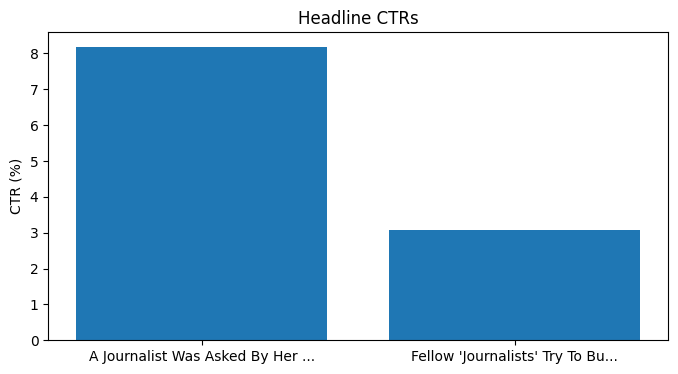

In [10]:
# 과제 5: 두 헤드라인의 클릭률 막대 차트 (교재 5-4 뼈대: figure → bar → ylabel → title → show)
# x축 이름은 헤드라인 앞 30자 — labels = [h[:30] + "..." for h in pair["headline"]]
labels = [h[:30] + "..." for h in pair["headline"]]
fig = plt.figure(figsize=(8, 4))   # TODO: plt.figure(figsize=(8, 4)) — 이 변수를 채점한다
plt.bar(labels, pair["ctr"] * 100)
plt.ylabel("CTR (%)")
plt.title("Headline CTRs")
plt.show()
# TODO: plt.bar(labels, 클릭률 %) / plt.ylabel("CTR (%)") / plt.title(...) / plt.show()

In [11]:
# [검증] 과제 5 — fig 안의 첫 축에서 막대 수·y축 라벨·제목을 본다
_ax = fig.axes[0] if (fig is not None and len(fig.axes) > 0) else None
check(5, bars=(len(_ax.patches) >= 2) if _ax is not None else None,
      ylabel=(_ax.get_ylabel() != "") if _ax is not None else None,
      title=(_ax.get_title() != "") if _ax is not None else None)

통과: 과제 5 (3개 항목 확인)


True

## 과제 6 — 차이가 우연인지 검정

강의 6절의 2표본 비율검정을 그대로 옮긴다. Cookie Cats에서는 성공이 "재접속"이었고 여기서는
"클릭"이다. 표본 수는 노출 수다.

- 요구사항: `proportions_ztest`로 `pair` 두 행의 클릭률 차이를 검정해 `z_stat`, `p_value`에 저장한다.
- 출력: `z_stat` (float), `p_value` (float, 0.001보다 훨씬 작아야 정상)
- 힌트: `proportions_ztest([클릭_위, 클릭_아래], [노출_위, 노출_아래])`. 위·아래 값은 과제 4처럼 `pair["clicks"].iloc[0]`, `.iloc[1]`로 꺼내거나, 열 전체 `pair["clicks"]`를 그대로 넘겨도 된다.
- **채점 항목**: `z_stat` (실수, 절댓값 기준 허용 오차 ±0.02), `p_value` (실수, 1e-20보다 작으면 통과). 교재 4-13와 같은 호출이며 성공 수는 클릭, 표본 수는 노출이다.

In [12]:
# 과제 6: 두 헤드라인의 클릭률 차이를 2표본 비율검정으로 판정한다
from statsmodels.stats.proportion import proportions_ztest
z_stat, p_value = proportions_ztest(
    pair["clicks"],
    pair["impressions"]
)   # TODO: z 통계량 (float) # TODO: p-value (float)

In [13]:
# [검증] 과제 6
check(6, z_abs=(abs(z_stat) if z_stat is not None else None, 0.02),
      p_tiny=(p_value < 1e-20) if p_value is not None else None)

통과: 과제 6 (2개 항목 확인)


True

## 과제 7 — 헤드라인 2개 실험을 한꺼번에 검정

방금 고른 실험 하나만 보면 "헤드라인을 바꾸면 클릭률이 달라진다"는 인상을 받는다. 그러나 그
실험은 차이가 큰 것을 고른 것이었다. 헤드라인 2개짜리 실험 전부에 같은 검정을 돌려 본다.

실험마다 반복하는 `for` 루프는 아래 셀에 뼈대로 주어져 있다(교재에서는 다루지 않았다). 루프는
`two_ids`에 든 실험을 하나씩 꺼내 그 실험의 두 행을 `g`에 담아 준다. 채울 곳은 두 군데다 —
루프 안에서 `g`의 클릭 수·노출 수로 검정을 호출하는 줄(과제 6과 같다)과, 루프가 끝난 뒤 유의한
비율을 구하는 줄이다.

- 요구사항: 실험마다 `proportions_ztest`로 p-value를 얻어 `pvals`에 모으고(뼈대가 한다), **유의수준
  5%에서 유의한 실험의 비율**을 `sig_share`에 저장한다. p-value가 `NaN`인 실험(두 헤드라인 모두
  클릭이 0)은 뼈대가 이미 걸러 낸다.
- 출력: `sig_share` (float)
- **채점 항목**: `sig_share` (실수, 0~1 사이의 비율, 허용 오차 ±0.01). 비율은 교재 4-10처럼
  참·거짓(0/1)의 평균으로 구한다 — `(pvals < 0.05).mean()`.

In [14]:
# 과제 7: 헤드라인 2개 실험 전부를 검정해 유의한 비율을 구한다 (루프 뼈대는 주어진다)
pvals = []
if arms is not None and two_ids is not None:          # 앞 과제를 아직 안 채웠으면 건너뛴다
    for _tid, g in arms[arms["test_id"].isin(two_ids)].groupby("test_id"):
        _z, _p = proportions_ztest(g["clicks"], g["impressions"])   # TODO: g["clicks"]와 g["impressions"]로 proportions_ztest (과제 6과 같다)
        if _p is not None and not np.isnan(_p):
            pvals.append(_p)
pvals = np.array(pvals)

sig_share = (pvals <= 0.05).mean()   # TODO: pvals 가운데 0.05 미만인 것의 비율 (불리언의 평균)

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


In [15]:
# [검증] 과제 7
check(7, sig_share=(sig_share, 0.01))

통과: 과제 7 (1개 항목 확인)


True

## 마무리

검증 셀 7개가 모두 "통과"를 출력하면 완료다. 관찰한 수치를 근거로 다음 질문에 한 문장씩 답해
노트북 끝에 마크다운으로 적고 제출한다.

- 과제 4의 두 헤드라인은 클릭률이 8.18%와 3.09%였다. 같은 기사에 붙인 제목만 바꾼 결과다.
  이 차이를 무엇의 효과라고 말할 수 있는가.
- 과제 7에서 유의한 실험의 비율은 약 31%였다. 아무 효과가 없는데도 우연히 유의해지는 비율은
  5%다. 이 둘의 차이는 무엇을 뜻하는가.
- 과제 2에서 헤드라인 단위로 합치지 않고 원래 행(헤드라인 × 이미지) 그대로 검정했다면
  무엇이 달라졌겠는가.

In [16]:
# 완료 확인 — 제출 전에 실행한다. 과제별 판정을 한 줄로 요약한다.
summary()

완료 확인: 전체 통과 (7개 과제)


True